#Adım 1: Problem Tanımı
Soru: Bir evin metrekare, oda sayısı, bina yaşı gibi fiziksel özelliklerine bakarak satış fiyatını doğru bir şekilde tahmin edebilir miyiz?

- Çıktı: Sürekli bir sayısal değer (Örn: 2.500.000 TL) ➔ Regresyon Problemi

- Özellikler (Bağımsız Değişkenler - X): Evin metrekaresi, oda sayısı, banyo sayısı, binanın yaşı gibi veriler.

- Hedef (Bağımlı Değişken - y): Evin Fiyatı.

- Plan: Veriyi hazırla ➔ keşfet ➔ modeli eğit ➔ tahmin et ➔ ölç.

# Adım 2: Kurulum ve Kütüphanelerin Yüklenmesi
Verilerle çalışmak, onları görselleştirmek ve makine öğrenmesi modelimizi kurmak için gerekli olan temel Python kütüphanelerini (Pandas, NumPy, Matplotlib, Seaborn ve Scikit-learn) çalışma ortamımıza dahil ediyoruz.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Kurulum tamamlandı. Kütüphaneler başarıyla içe aktarıldı! 🚀")

Kurulum tamamlandı. Kütüphaneler başarıyla içe aktarıldı! 🚀


# Adım 3: Veriyi Oku ve Tanı
Veri setimizi internet üzerinden Pandas kütüphanesini kullanarak projemize dahil ediyoruz. Veriyi okuduktan sonra head() fonksiyonu ile ilk 5 satırına göz atıp, info() fonksiyonu ile veri tiplerini ve eksik veri olup olmadığını inceleyeceğiz.

In [ ]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

print("--- Veri Setinin İlk 5 Satırı ---")
display(df.head())

print("\n--- Veri Seti Genel Bilgileri ---")
df.info()

--- Veri Setinin İlk 5 Satırı ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Veri Seti Genel Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Adım 4: Veriyi Temizleme ve Ön İşleme
Veri setimizdeki eksik (NaN) değerleri tespit edip uygun yöntemle (ortanca değer ile) dolduracağız. Ayrıca makine öğrenmesi modelleri sadece sayılarla çalıştığı için, metin formatındaki kategorik verilerimizi (okyanusa yakınlık durumu) sayısal formatlara dönüştüreceğiz (One-Hot Encoding).

In [ ]:
# 1. EKSİK VERİLERİ DOLDURMA
median_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)

print("Eksik veri kontrolü (Hepsi 0 olmalı):\n")
print(df.isnull().sum())

# 2. KATEGORİK VERİYİ SAYISALLAŞTIRMA (One-Hot Encoding)
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

print("\n--- Temizlenmiş ve İşlenmiş Verinin İlk 5 Satırı ---")
display(df.head())

Eksik veri kontrolü (Hepsi 0 olmalı):

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

--- Temizlenmiş ve İşlenmiş Verinin İlk 5 Satırı ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


#Adım 5: Keşifçi Veri Analizi (EDA) ve Görselleştirme
Verimizi temizlediğimize göre, artık verinin içindeki gizli hikayeleri (içgörüleri) ortaya çıkarabiliriz. Özelliklerin birbiriyle ve özellikle hedef değişkenimiz olan "ev fiyatı" ile ilişkisini anlamak için korelasyon matrisi (ısı haritası) oluşturacağız. Ardından evlerin konumlarına (enlem/boylam) göre fiyat dağılımını görselleştireceğiz.

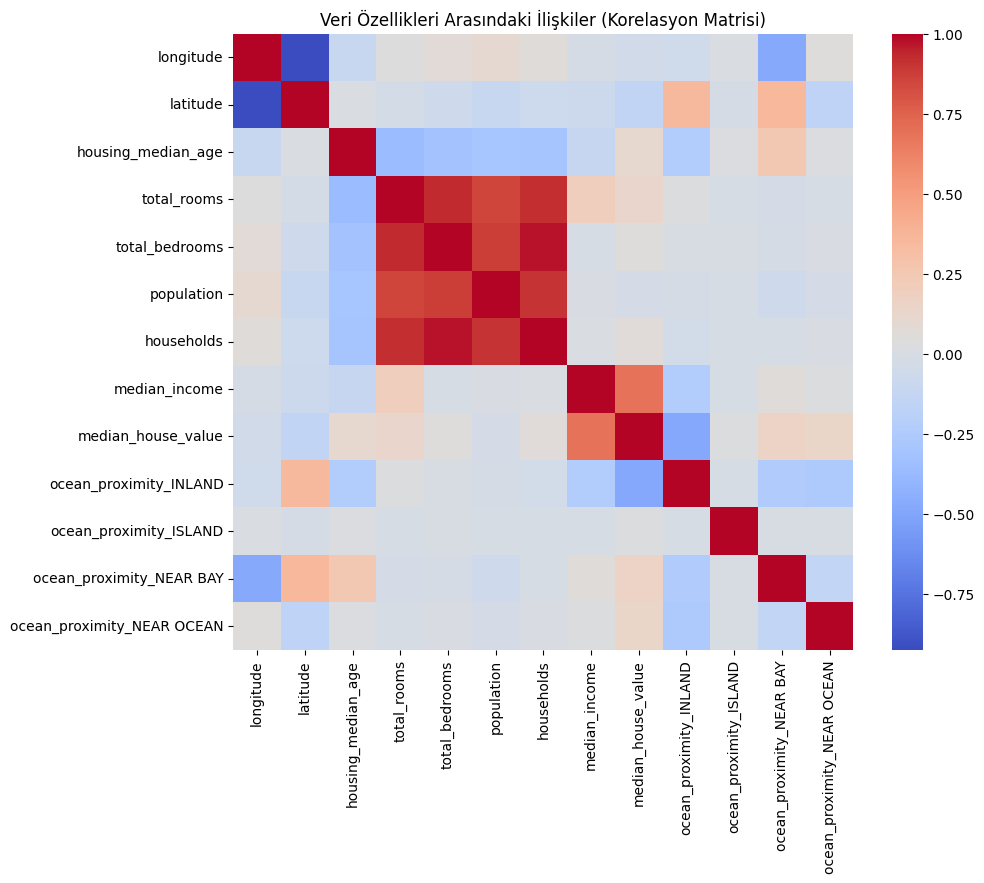

--- Ev Fiyatını En Çok Etkileyen Özellikler ---
median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
Name: median_house_value, dtype: float64




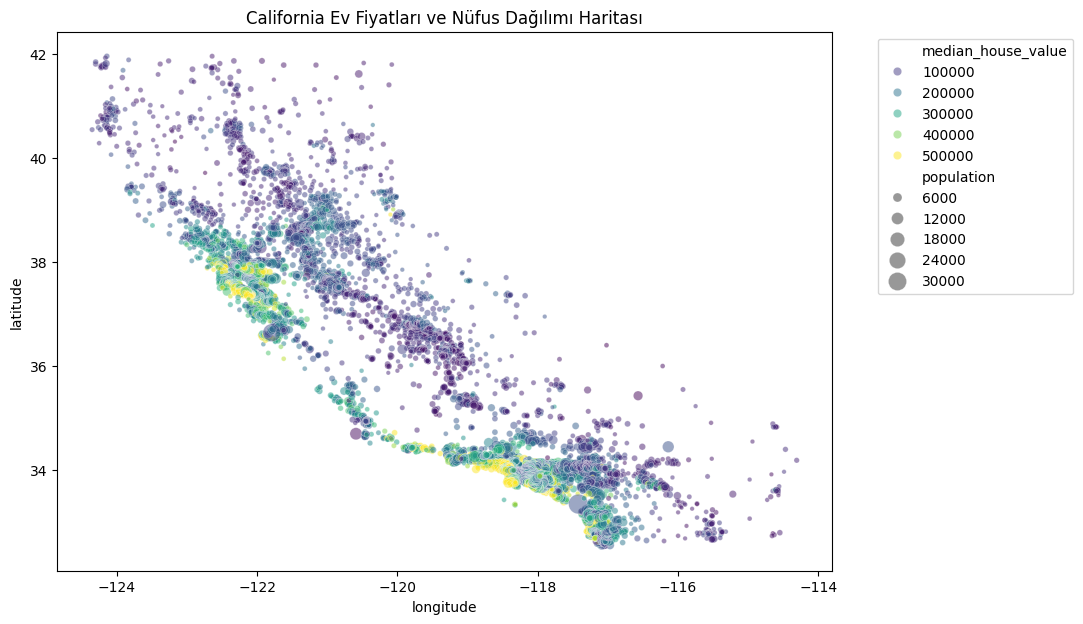

In [ ]:
# 1. KORELASYON MATRİSİ (Isı Haritası)
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Veri Özellikleri Arasındaki İlişkiler (Korelasyon Matrisi)')
plt.show()

print("--- Ev Fiyatını En Çok Etkileyen Özellikler ---")
print(corr_matrix["median_house_value"].sort_values(ascending=False).head(5))
print("\n" + "="*50 + "\n")

# 2. COĞRAFİ DAĞILIM VE FİYAT HARİTASI
plt.figure(figsize=(10, 7))
sns.scatterplot(x='longitude', y='latitude', data=df,
                hue='median_house_value', palette='viridis',
                size='population', sizes=(10, 200), alpha=0.5)
plt.title('California Ev Fiyatları ve Nüfus Dağılımı Haritası')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Adım 6: Model Kur ve Eğit
"Problem ➔ Veri ➔ Model ➔ Sonuç" haritamızın Model aşamasındayız. Özelliklerimizi (X) ve hedef değişkenimizi (y) ayırıp, verimizi %80 Eğitim (Train) ve %20 Test (Test) olacak şekilde bölüyoruz. Ardından Random Forest Regressor algoritması ile modelimizi veriden öğrenecek şekilde eğitiyoruz.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. X (Özellikler) ve y (Hedef) Belirleme
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# 2. Veriyi Eğitim (%80) ve Test (%20) Olarak Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim (Antrenman) verisi satır sayısı: {X_train.shape[0]}")
print(f"Test (Sınav) verisi satır sayısı: {X_test.shape[0]}")

# 3. Modeli Kurma ve Eğitme
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Tebrikler! Model verilerden öğrendi ve başarıyla eğitildi.")

Eğitim (Antrenman) verisi satır sayısı: 16512
Test (Sınav) verisi satır sayısı: 4128
Tebrikler! Model verilerden öğrendi ve başarıyla eğitildi.


#Adım 7: Model Değerlendirme
Modelimizin daha önce hiç görmediği test verileri (%20) üzerinde ne kadar iyi performans gösterdiğini ölçüyoruz. Bunun için R-Kare (Başarı oranı), MAE (Ortalama Mutlak Hata) ve RMSE gibi regresyon metriklerini kullanacağız. Ayrıca gerçek fiyatlar ile modelin tahminlerini yan yana koyarak bir grafik çizeceğiz.

--- Model Sınav Karnesi ---
Ortalama Mutlak Yanılma Payı (MAE): 31,639 Dolar
Modelin Başarı Oranı (R2 Skoru): % 81.65


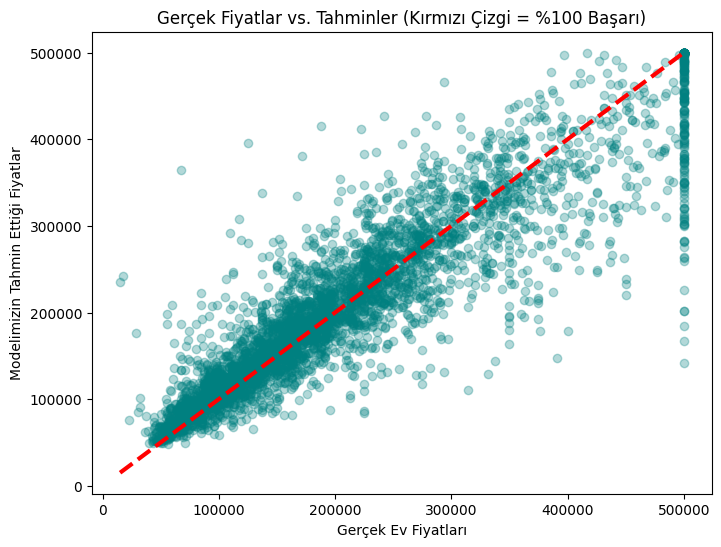

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Tahmin Yapma
y_pred = model.predict(X_test)

# 2. Hataları ve Başarıyı Ölçme
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Sınav Karnesi ---")
print(f"Ortalama Mutlak Yanılma Payı (MAE): {mae:,.0f} Dolar")
print(f"Modelin Başarı Oranı (R2 Skoru): % {r2*100:.2f}")

# 3. Gerçek vs Tahmin Grafiği
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.xlabel('Gerçek Ev Fiyatları')
plt.ylabel('Modelimizin Tahmin Ettiği Fiyatlar')
plt.title('Gerçek Fiyatlar vs. Tahminler (Kırmızı Çizgi = %100 Başarı)')
plt.show()

#Adım 8: Akıllı Tahmin Aracı
Modelimizi eğittik ve test ettik. Şimdi sıra onu gerçek dünyada (veya hayalimizde) kullanmakta! Özelliklerini bizim belirlediğimiz, daha önce veri setinde hiç bulunmayan yepyeni bir evin özelliklerini modelimize verip "Sence bu ev ne kadar eder?" diye soracağız.

In [ ]:
# 1. Hayalimizdeki Evi Oluşturalım
yeni_ev = {
    "longitude": 122.23,         # Boylam
    "latitude": 37.88,            # Enlem
    "housing_median_age": 15,     # Bina Yaşı (15 yıllık bina)
    "total_rooms": 12,          # Toplam Oda Sayısı
    "total_bedrooms": 250,        # Toplam Yatak Odası
    "population": 400,            # Çevredeki Nüfus
    "households": 150,            # Çevredeki Hane Sayısı
    "median_income": 8.5,         # Bölgedeki Medyan Gelir (85.000$ - Oldukça zengin bir bölge)
    "ocean_proximity_INLAND": 0,  # İç kesimde mi? (0 = Hayır)
    "ocean_proximity_ISLAND": 0,  # Adada mı? (0 = Hayır)
    "ocean_proximity_NEAR BAY": 1,# Körfeze yakın mı? (1 = Evet)
    "ocean_proximity_NEAR OCEAN": 0 # Okyanusa yakın mı? (0 = Hayır)
}

# 2. Bu bilgileri modelin anlayacağı formata (Pandas DataFrame) çeviriyoruz
yeni_ev_df = pd.DataFrame([yeni_ev], columns=X.columns)
yeni_ev_df = yeni_ev_df.fillna(0)

# 3. Modelden Tahmini Alalım
tahmin_edilen_fiyat = model.predict(yeni_ev_df)[0]

print(" --- YAPAY ZEKA GAYRİMENKUL DANIŞMANI --- \n")
print("Girdiğiniz ev özelliklerine bakıyorum...")
print(f"Bu özelliklere sahip bir evin tahmini satış fiyatı: {tahmin_edilen_fiyat:,.2f} Dolar ")

 --- YAPAY ZEKA GAYRİMENKUL DANIŞMANI --- 

Girdiğiniz ev özelliklerine bakıyorum...
Bu özelliklere sahip bir evin tahmini satış fiyatı: 394,814.22 Dolar 


#Adım 9: Sonuç ve Kapanış
Başlangıçta belirlediğimiz "Problem ➔ Veri ➔ Model ➔ Sonuç" haritasını adım adım uygulayarak projemizi başarıyla tamamladık.

- Problem: Bir evin fiziksel ve coğrafi özelliklerine bakarak fiyatını tahmin edebilecek bir dar yapay zeka (regresyon) modeli geliştirmek üzere yola çıktık.

- Veri: İnternet üzerinden Pandas ile California ev fiyatları veri setini çektik. Eksik verileri (yatak odası sayıları) ortanca değer ile doldurduk ve kategorik metin verilerini makinenin anlayacağı sayılara dönüştürerek veriyi temizledik.

- Model: Random Forest (Rastgele Orman) algoritmasını kurduk ve verimizin %80'ini kullanarak bu modeli eğittik.

- Sonuç: Modelimiz, daha önce hiç görmediği test verilerinde yüksek bir başarı oranı (R2 Skoru) elde etti. En sonunda ise kendi "Akıllı Tahmin Aracımızı" yazarak, hayalimizdeki bir evin fiyatını modele başarılı bir şekilde tahmin ettirdik.